# Histopathologic Cancer Detection Deep Model

<center>
    <h3>Utilizing deep learning to detect cancer in histopathologic images.</h3><br>
    <h5>By: Michael Hansen</h5>
    <h5>Date: 02/04/2025</h5>
    <h5>Course: DTSA5511 Deep Learning</h5>
    <h5>Instructor: Dr. Ying Sun</h5>
</center>


This notebook is an exploration into Deep Learning and it's use to detect cancer in histopathologic images. The dataset provided in this Kaggle competition is a collection of histopathologic images of breast cancer tumors. The goal is to build a model that can accurately detect cancer in these images.

The importance of being able to perform this task with a deep learning model cannot be understated as the benifits are too numerous to count. Thankfully there is a host of brilliant minds that have made a suite of tools that make this task easier. For this project I will be using the [Keras](https://keras.io/) library to build my model, and using ideas such as pooling, dropout, and batch normalization to improve the performance of my model.

The dataset can be found [here](https://www.kaggle.com/competitions/histopathologic-cancer-detection/data), and was originally obtained from the [TCGA](https://portal.gdc.cancer.gov/projects/TCGA-BRCA) project. The group at kaggle removed duplicates that originated from probablistic sampling. There are roughly 220,000 labeled images for training and about 57,000 for the test set.


In [26]:
# Importing Libraries

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt # plotting
from plotly.subplots import make_subplots # plotting
import plotly.graph_objs as go # plotting

from concurrent.futures import ThreadPoolExecutor
import multiprocessing
import cv2 # image processing
import gc # Clear Memory
from glob import glob # file handling
import os # file handling
from tqdm import tqdm

# deep learning
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, Flatten, BatchNormalization, Activation, Conv2D, MaxPool2D, Input, GlobalAveragePooling2D
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, TensorBoard, CSVLogger, ReduceLROnPlateau  # You might use these later
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.utils import shuffle
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.model_selection import train_test_split


In [27]:
# file_path = 'G:/My Drive/Academia/C Data/'
file_path = 'E:/CDAT/'
train_path = file_path + "train/"
test_path = file_path + "test/"


labels = pd.read_csv(file_path + "train_labels.csv")
print("labels")
labels.head()



#final_data_frame = pd.concat([train_data_frame, test_data_frame]).reset_index(drop = True)

labels


,id,label
0,f38a6374c348f90b587e046aac6079959adf3835,0
1,c18f2d887b7ae4f6742ee445113fa1aef383ed77,1
2,755db6279dae599ebb4d39a9123cce439965282d,0
3,bc3f0c64fb968ff4a8bd33af6971ecae77c75e08,0
4,068aba587a4950175d04c680d38943fd488d6a9d,0


In [28]:

train_data_frame = pd.DataFrame({'path': [p.replace('\\', '/') for p in glob(os.path.join(train_path,'*.tif'))]})
train_data_frame['id'] = train_data_frame.path.map(lambda x: x.split('/')[3].split(".")[0])
df_data = train_data_frame.merge(labels, on = "id")
print("train")
df_data.head()

print(len(train_data_frame))

train
220025


In [29]:
test_data_frame = pd.DataFrame({'path': [p.replace('\\', '/') for p in glob(os.path.join(test_path,'*.tif'))]})

test_data_frame['id'] = test_data_frame.path.map(lambda x: x.split('/')[3].split(".")[0])
print("test")
print(len(test_data_frame))
test_data_frame.head()


test
57458


,path,id
0,E:/CDAT/test/00006537328c33e284c973d7b39d34080...,00006537328c33e284c973d7b39d340809f7271b
1,E:/CDAT/test/0000ec92553fda4ce39889f9226ace43c...,0000ec92553fda4ce39889f9226ace43cae3364e
2,E:/CDAT/test/00024a6dee61f12f7856b0fc6be20bc7a...,00024a6dee61f12f7856b0fc6be20bc7a48ba3d2
3,E:/CDAT/test/000253dfaa0be9d0d100283b22284ab2f...,000253dfaa0be9d0d100283b22284ab2f6b643f6
4,E:/CDAT/test/000270442cc15af719583a8172c87cd2b...,000270442cc15af719583a8172c87cd2bd9c7746


In [30]:
def load_sample_images(data_frame, num_samples=12):
    """Load a small number of sample images for visualization"""
    # Randomly sample from the dataframe
    sample_df = data_frame.sample(n=num_samples)
    
    # Load the images
    images = []
    labels = []
    for _, row in sample_df.iterrows():
        img = cv2.imread(row['path'])
        # Convert BGR to RGB
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        images.append(img)
        labels.append(row['label'])
    
    return np.array(images), np.array(labels)

In [31]:
X_samples, y_samples = load_sample_images(df_data, num_samples=12)


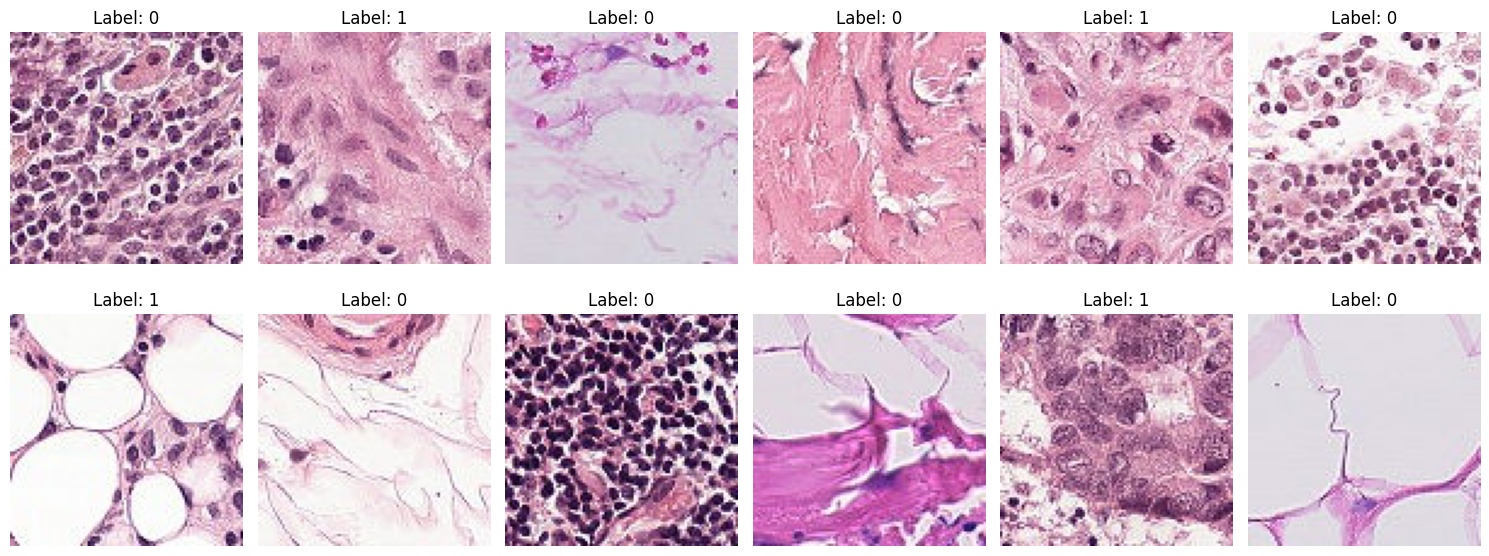


Label distribution in displayed samples:
Label 0: 8 images
Label 1: 4 images

Total dataset label distribution:
Label 0: 130908 images (59.5%)
Label 1: 89117 images (40.5%)


In [32]:
# Display a few sample images with their labels
plt.figure(figsize=(15,6))
for plotNr in range(len(X_samples)):
    ax = plt.subplot(2, len(X_samples)//2, plotNr+1)
    plt.imshow(X_samples[plotNr])
    plt.title(f'Label: {y_samples[plotNr]}')
    plt.axis('off')

plt.tight_layout()
plt.show()

# Print distribution of labels in our sample
print(f"\nLabel distribution in displayed samples:")
unique, counts = np.unique(y_samples, return_counts=True)
for label, count in zip(unique, counts):
    print(f"Label {label}: {count} images")

print(f"\nTotal dataset label distribution:")
label_counts = df_data['label'].value_counts()
for label, count in label_counts.items():
    print(f"Label {label}: {count} images ({count/len(df_data)*100:.1f}%)")


Describe images

In [33]:
# Lay out the size and shape of the test and train

# Quick check for duplicates and NA

Describe the Data info & cleaning

Now we want to see if there is any distiguishable features we can look for visually ourselves. 
According to 
https://www.ncbi.nlm.nih.gov/books/NBK9553/#:~:text=Morphologically%2C%20the%20cancerous%20cell%20is,prominent%2C%20the%20cytoplasm%20is%20scarce
you can see differences in the size, shape, and potentially color of the cells in the images. This is good reason to dive into attributes of the pixels deeper. Each pixel has 3 channels, red, green, and blue. We can see that these are set on a scale from 0 to 255, 0 being the darkest of the color. 

And right there we have two characteristics. Brightness and Color. Both of these match characteristics listed in the article above so lets check it out. 

Comparing pairwise images would be impossible with data of this size and the resources / time at hand. What we can do is compare the amounts of each channel in each! The total sum gives the colors and the average will then give the brightness. 

In [34]:
#  Establish a new dataframe that puts an entry for each image, with the amount of R, G, and B in each image


In [35]:
# Graph

In [36]:
# Create an ImageDataGenerator instance with desired augmentations
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

validation_datagen = ImageDataGenerator(rescale=1./255)


Text(0, 0.5, '# of samples')

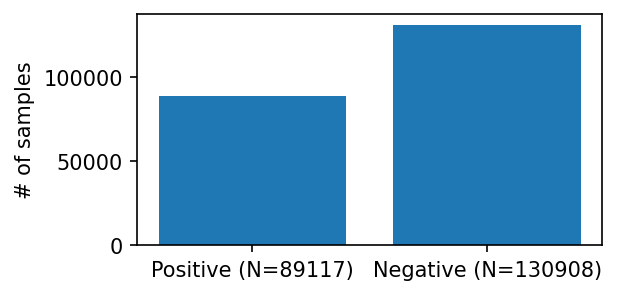

In [37]:
# Distribution statistic
fig = plt.figure(figsize=(4, 2),dpi=150)
plt.bar([1,0], [len(df_data[df_data['label']==0]), len(df_data[df_data['label']==1])]); #plot a bar chart of the label frequency
plt.xticks([1,0],["Negative (N={})".format(len(df_data[df_data['label']==0])),"Positive (N={})".format(len(df_data[df_data['label']==1]))]);
plt.ylabel("# of samples")

Describe

In [38]:
# split data
positive_samples = df_data[df_data['label'] == 1]
negative_samples = df_data[df_data['label'] == 0]

In [39]:
def load_batch_images(dataframe, batch_size=100):
    """Load and preprocess a batch of images from dataframe"""
    images = []
    for _, row in dataframe.head(batch_size).iterrows():
        img = cv2.imread(row['path'])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = img / 255.0  # Normalize to match training preprocessing
        images.append(img)
    return np.array(images)

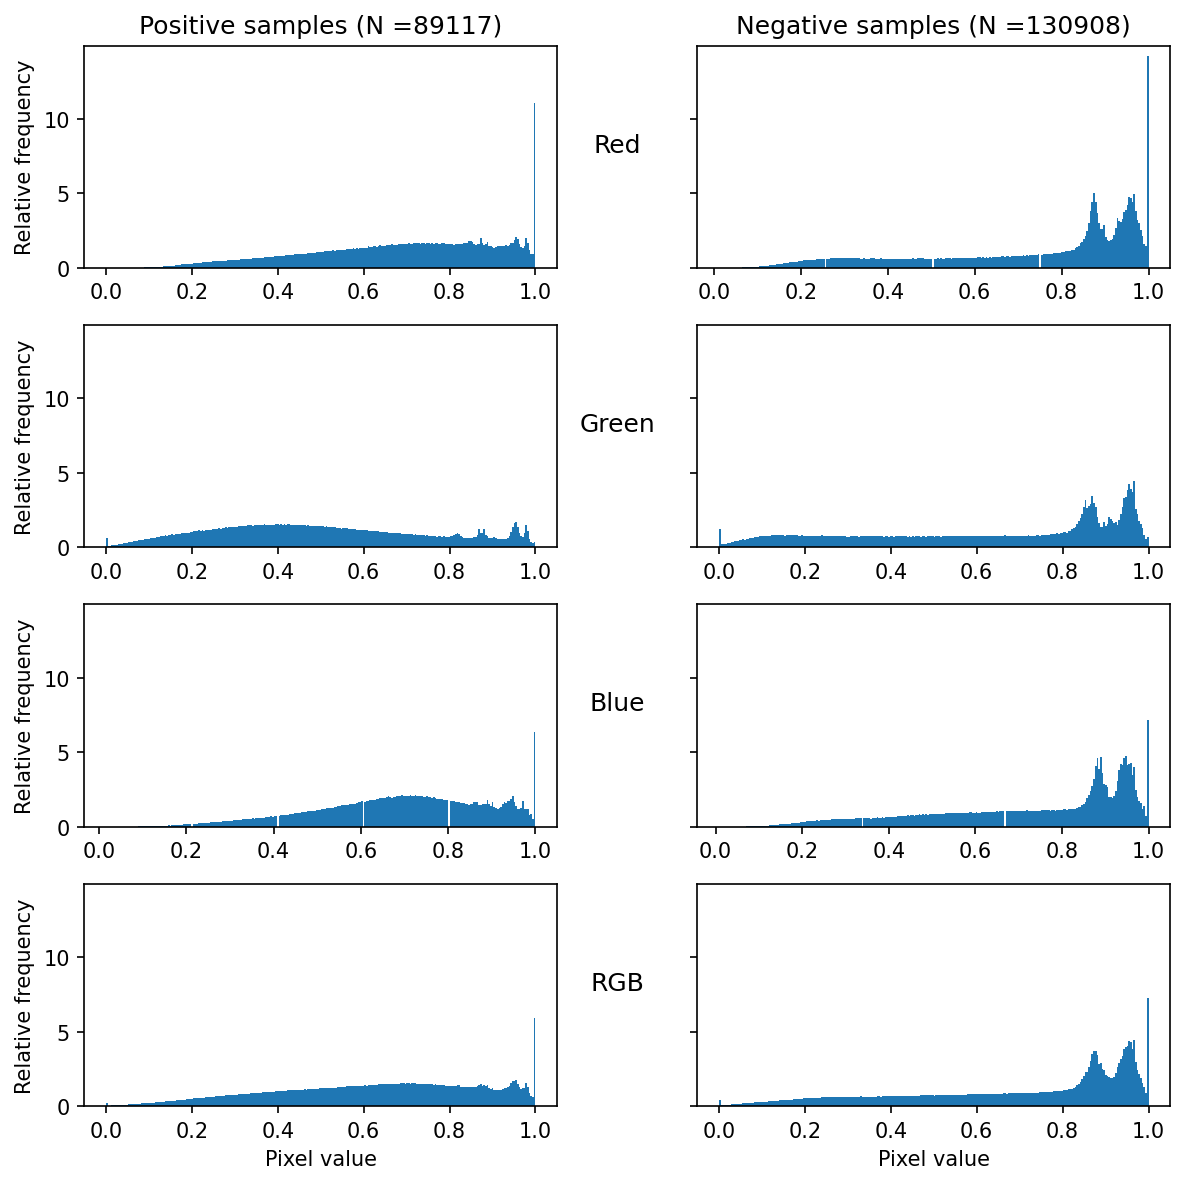

In [40]:
nr_of_bins = 256 #each possible pixel value will get a bin in the following histograms
fig,axs = plt.subplots(4,2,sharey=True,figsize=(8,8),dpi=150)

# Get sample images for positive and negative cases
pos_batch = load_batch_images(positive_samples, batch_size=100)
neg_batch = load_batch_images(negative_samples, batch_size=100)

pos_images = pos_batch
neg_images = neg_batch

#RGB channels
axs[0,0].hist(pos_images[:,:,:,0].flatten(),bins=nr_of_bins,density=True)
axs[0,1].hist(neg_images[:,:,:,0].flatten(),bins=nr_of_bins,density=True)
axs[1,0].hist(pos_images[:,:,:,1].flatten(),bins=nr_of_bins,density=True)
axs[1,1].hist(neg_images[:,:,:,1].flatten(),bins=nr_of_bins,density=True)
axs[2,0].hist(pos_images[:,:,:,2].flatten(),bins=nr_of_bins,density=True)
axs[2,1].hist(neg_images[:,:,:,2].flatten(),bins=nr_of_bins,density=True)

#All channels
axs[3,0].hist(pos_images.flatten(),bins=nr_of_bins,density=True)
axs[3,1].hist(neg_images.flatten(),bins=nr_of_bins,density=True)

#Set image labels
axs[0,0].set_title("Positive samples (N =" + str(len(positive_samples)) + ")");
axs[0,1].set_title("Negative samples (N =" + str(len(negative_samples)) + ")");
axs[0,1].set_ylabel("Red",rotation='horizontal',labelpad=35,fontsize=12)
axs[1,1].set_ylabel("Green",rotation='horizontal',labelpad=35,fontsize=12)
axs[2,1].set_ylabel("Blue",rotation='horizontal',labelpad=35,fontsize=12)
axs[3,1].set_ylabel("RGB",rotation='horizontal',labelpad=35,fontsize=12)
for i in range(4):
    axs[i,0].set_ylabel("Relative frequency")
axs[3,0].set_xlabel("Pixel value")
axs[3,1].set_xlabel("Pixel value")
fig.tight_layout()

In [41]:
N = df_data["path"].size # get the number of images in the training data set
print(N)

220025


In [42]:
# Changed to 1000 for testing
#X,y = load_data(N=N,data_frame=df_data)
#froze ~47 minutes 


In [43]:

gc.collect();

In [44]:
kernel_size = (3, 3)
pool_size = (2, 2)
first_filters = 32
second_filters = 64
third_filters = 128
dropout_conv = 0.4  # Slightly increased
dropout_dense = 0.5
l2_reg = 0.001  # L2 regularization strength

inputs = Input(shape=(96, 96, 3))

# Conv block 1
x = Conv2D(first_filters, kernel_size, kernel_regularizer=l2(l2_reg), kernel_initializer='he_normal')(inputs)
x = BatchNormalization()(x)
x = Activation("relu")(x)
x = Conv2D(first_filters, kernel_size, use_bias=False, kernel_regularizer=l2(l2_reg), kernel_initializer='he_normal')(x)
x = BatchNormalization()(x)
x = Activation("relu")(x)
x = MaxPool2D(pool_size=pool_size)(x)
x = Dropout(dropout_conv)(x)

# Conv block 2
x = Conv2D(second_filters, kernel_size, use_bias=False, kernel_regularizer=l2(l2_reg), kernel_initializer='he_normal')(x)
x = BatchNormalization()(x)
x = Activation("relu")(x)
x = Conv2D(second_filters, kernel_size, use_bias=False, kernel_regularizer=l2(l2_reg), kernel_initializer='he_normal')(x)
x = BatchNormalization()(x)
x = Activation("relu")(x)
x = MaxPool2D(pool_size=pool_size)(x)
x = Dropout(dropout_conv)(x)

# Conv block 3
x = Conv2D(third_filters, kernel_size, use_bias=False, kernel_regularizer=l2(l2_reg), kernel_initializer='he_normal')(x)
x = BatchNormalization()(x)
x = Activation("relu")(x)
x = Conv2D(third_filters, kernel_size, use_bias=False, kernel_regularizer=l2(l2_reg), kernel_initializer='he_normal')(x)
x = BatchNormalization()(x)
x = Activation("relu")(x)
x = MaxPool2D(pool_size=pool_size)(x)
x = Dropout(dropout_conv)(x)

# Fully connected layer
x = Flatten()(x)
x = Dense(256, use_bias=False, kernel_initializer='he_normal')(x)
x = BatchNormalization()(x)
x = Activation("relu")(x)
x = Dropout(dropout_dense)(x)

# Output layer
outputs = Dense(1, activation="sigmoid")(x)



In [45]:
model = Model(inputs=inputs, outputs=outputs)

In [46]:
batch_size = 32

# Split data *before* creating generators (important for consistent validation sets)
X_train, X_val, y_train, y_val = train_test_split(df_data, df_data['label'], test_size=0.2, random_state=42)
# Reset the indices for both
X_train = X_train.reset_index(drop=True)
X_val = X_val.reset_index(drop=True)
X_train['label'] = X_train['label'].astype(str)
X_val['label'] = X_val['label'].astype(str)

train_generator = datagen.flow_from_dataframe(
    dataframe=X_train,
    x_col="path",  # Column containing image paths
    y_col="label",  # Column containing labels
    target_size=(96, 96),
    batch_size=batch_size,
    class_mode='binary',  # 'binary' for binary classification, 'categorical' for multi-class
    shuffle=True  # Shuffle the training data
)

validation_generator = validation_datagen.flow_from_dataframe(
    dataframe=X_val,
    x_col="path",
    y_col="label",
    target_size=(96, 96),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False  # Don't shuffle the validation data
)

model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(96, 96, 3)),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

steps_per_epoch = len(X_train) // batch_size
validation_steps = len(X_val) // batch_size

model.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch,
    epochs=5,  # Adjust epochs as needed
    validation_data=validation_generator,
    validation_steps=validation_steps
)

Found 176020 validated image filenames belonging to 2 classes.
Found 44005 validated image filenames belonging to 2 classes.
Epoch 1/5


c:\Users\Belgarath\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\Belgarath\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


5500/5500 ━━━━━━━━━━━━━━━━━━━━ 325s 59ms/step - accuracy: 0.7619 - loss: 0.5302 - val_accuracy: 0.7719 - val_loss: 0.5275
Epoch 2/5
   1/5500 ━━━━━━━━━━━━━━━━━━━━ 2:50 31ms/step - accuracy: 0.8438 - loss: 0.2822

c:\Users\Belgarath\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\trainers\epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


5500/5500 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.8438 - loss: 0.2822 - val_accuracy: 0.7618 - val_loss: 0.5552
Epoch 3/5
5500/5500 ━━━━━━━━━━━━━━━━━━━━ 323s 59ms/step - accuracy: 0.8006 - loss: 0.4392 - val_accuracy: 0.7229 - val_loss: 0.6133
Epoch 4/5
5500/5500 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.8438 - loss: 0.3198 - val_accuracy: 0.7225 - val_loss: 0.6129
Epoch 5/5
5500/5500 ━━━━━━━━━━━━━━━━━━━━ 322s 59ms/step - accuracy: 0.8075 - loss: 0.4245 - val_accuracy: 0.7715 - val_loss: 0.5215


In [48]:
complex_model = tf.keras.Model(inputs=inputs, outputs=outputs)
checkpoint_path = "model_checkpoints/best_model_v3.keras"
os.makedirs(os.path.dirname(checkpoint_path), exist_ok=True)

# Calculate steps per epoch (important for CosineDecayRestarts)
steps_per_epoch_complex = train_generator.n // train_generator.batch_size
validation_steps_complex = validation_generator.n // validation_generator.batch_size


initial_learning_rate = 0.0001
lr_schedule = tf.keras.optimizers.schedules.CosineDecayRestarts(
    initial_learning_rate,
    first_decay_steps=steps_per_epoch_complex,  # Use calculated steps_per_epoch
    t_mul=2.0,
    m_mul=0.9,
    alpha=0.0001
)
optimizer = Adam(learning_rate=lr_schedule)
#optimizer = tf.keras.optimizers.SGD(learning_rate=lr_schedule, momentum=0.9) #Try SGD

callbacks = [
    ModelCheckpoint(
        checkpoint_path,
        monitor='val_accuracy',
        verbose=1,
        save_best_only=True,
        mode='max',
        save_weights_only=False
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=10, #Give more time to learn
        restore_best_weights=True,
        verbose=1
    ),
    CSVLogger('training_history.csv'),
    TensorBoard(
        log_dir='./logs',
        histogram_freq=1
    )
]

# --- Train the Complex Model ---
complex_model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy']) # Compile before training

history = complex_model.fit(
    train_generator,  # Use the *same* generator as the simple model
    steps_per_epoch=steps_per_epoch_complex,
    epochs=10,  # Increased epochs (rely on EarlyStopping)
    validation_data=validation_generator,  # Use the *same* generator
    validation_steps=validation_steps_complex,
    callbacks=callbacks
)

# Save training history
history_dict = history.history
np.save('training_history.npy', history_dict)

Epoch 1/10
5500/5500 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.8732 - loss: 0.3482
Epoch 1: val_accuracy improved from -inf to 0.84109, saving model to model_checkpoints/best_model_v3.keras
5500/5500 ━━━━━━━━━━━━━━━━━━━━ 643s 117ms/step - accuracy: 0.8732 - loss: 0.3482 - val_accuracy: 0.8411 - val_loss: 0.4453
Epoch 2/10
   1/5500 ━━━━━━━━━━━━━━━━━━━━ 9:38 105ms/step - accuracy: 0.9375 - loss: 0.2506
Epoch 2: val_accuracy did not improve from 0.84109
5500/5500 ━━━━━━━━━━━━━━━━━━━━ 31s 6ms/step - accuracy: 0.9375 - loss: 0.2506 - val_accuracy: 0.8391 - val_loss: 0.4498
Epoch 3/10
5500/5500 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.8827 - loss: 0.3264
Epoch 3: val_accuracy improved from 0.84109 to 0.84634, saving model to model_checkpoints/best_model_v3.keras
5500/5500 ━━━━━━━━━━━━━━━━━━━━ 640s 116ms/step - accuracy: 0.8827 - loss: 0.3264 - val_accuracy: 0.8463 - val_loss: 0.4350
Epoch 4/10
   1/5500 ━━━━━━━━━━━━━━━━━━━━ 10:32 115ms/step - accuracy: 0.8750 - loss: 0.2602
E

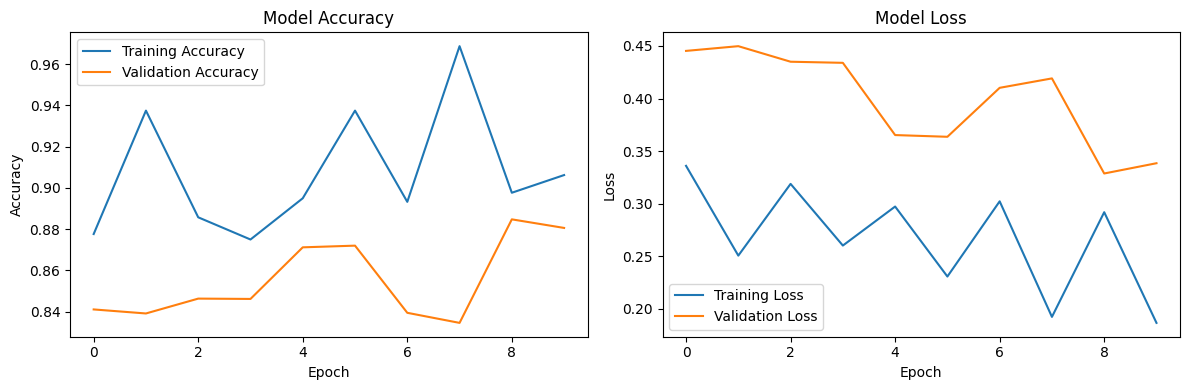

In [49]:
# To load the model and history later, you can use:
def load_model_and_history():
    loaded_model = tf.keras.models.load_model(checkpoint_path)
    loaded_history = np.load('training_history.npy', allow_pickle=True).item()
    return loaded_model, loaded_history

# Optional: Plot training history
def plot_training_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # Plot accuracy
    ax1.plot(history['accuracy'], label='Training Accuracy')
    ax1.plot(history['val_accuracy'], label='Validation Accuracy')
    ax1.set_title('Model Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    
    # Plot loss
    ax2.plot(history['loss'], label='Training Loss')
    ax2.plot(history['val_loss'], label='Validation Loss')
    ax2.set_title('Model Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    
    plt.tight_layout()
    plt.show()

# Plot the training history
plot_training_history(history.history)

In [43]:
# loaded_model, loaded_history = load_model_and_history()

# Explain training

In [50]:
# Validation on test data
test_size = len(X_val)  # Use the validation set we created earlier
iterations = np.floor(test_size / batch_size).astype(int)
loss, acc = 0, 0

# Use the existing validation generator we created earlier
validation_predictions = model.predict(
    validation_generator,
    steps=validation_steps,
    verbose=1
)

# Calculate metrics using the validation data
val_loss, val_accuracy = model.evaluate(
    validation_generator,
    steps=validation_steps,
    verbose=1
)

print("\nValidation loss:", val_loss)
print("Validation accuracy:", val_accuracy)



1375/1375 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.7733 - loss: 0.5165

Validation loss: 0.5214908719062805
Validation accuracy: 0.7714999914169312


# Explain Validation

In [51]:
# Submission
submission = pd.DataFrame() #create a dataframe to hold results
max_idx = len(test_data_frame) #get total number of test samples
file_batch = 1000

for idx in tqdm(range(0, max_idx, file_batch), desc="Processing test batches", unit="batch"):
    batch_df = test_data_frame.iloc[idx:idx+file_batch].copy()
    
    # Load and preprocess images using same process as training
    batch_images = []
    for path in batch_df['path']:
        img = cv2.imread(path)
        # Convert BGR to RGB if needed
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        batch_images.append(img)
    
    K_test = np.array(batch_images)
    predictions = model.predict(K_test, verbose=1)
    
    # Ensure predictions are properly formatted
    predictions = predictions.flatten()
    batch_df['label'] = predictions
    
    # Add batch results to submission dataframe
    submission = pd.concat([submission, batch_df[["id", "label"]]])

Processing test batches:   0%|          | 0/58 [00:00<?, ?batch/s]

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


Processing test batches:   2%|▏         | 1/58 [00:00<00:40,  1.42batch/s]

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


Processing test batches:   3%|▎         | 2/58 [00:01<00:35,  1.57batch/s]

...

Processing test batches:  97%|█████████▋| 56/58 [00:33<00:01,  1.65batch/s]

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


Processing test batches:  98%|█████████▊| 57/58 [00:34<00:00,  1.64batch/s]

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


Processing test batches: 100%|██████████| 58/58 [00:34<00:00,  1.67batch/s]


In [52]:
submission.to_csv("submission.csv", index = False, header = True) #create the submission file